In [2]:
from langgraph.graph import START, END, StateGraph, add_messages, MessagesState
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, RemoveMessage
from langchain_core.runnables import Runnable
from typing import Literal, Annotated
from collections.abc import Sequence

In [59]:
my_list = add_messages([
    HumanMessage(content="Hi, how are you?"),
    AIMessage(content="I'm doing great! How can I help you?"),
    HumanMessage(content="What is LangChain?"),
    AIMessage(content="LangChain is a framework for building LLM-powered applications."),
    HumanMessage(content="What is RAG?"),
    AIMessage(content="RAG stands for Retrieval-Augmented Generation."),
    HumanMessage(content="What is an LLM?"),
    AIMessage(content="LLM stands for Large Language Model."),
    HumanMessage(content="What are AI agents?"),
    AIMessage(content="AI agents can reason, use tools, and take actions to achieve goals."),
    AIMessage(content="You want to ask another question?")],
    [HumanMessage("yes")])

my_list

[HumanMessage(content='Hi, how are you?', additional_kwargs={}, response_metadata={}, id='f0e0f165-9c04-4480-8f1b-e2bd0797d83b'),
 AIMessage(content="I'm doing great! How can I help you?", additional_kwargs={}, response_metadata={}, id='913d9509-6b00-4646-a61a-c1c2d5824d11', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='What is LangChain?', additional_kwargs={}, response_metadata={}, id='34e542be-0797-41c3-a369-a4154f9c71ed'),
 AIMessage(content='LangChain is a framework for building LLM-powered applications.', additional_kwargs={}, response_metadata={}, id='5bb3e316-b090-401f-a232-8792a1829c12', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='What is RAG?', additional_kwargs={}, response_metadata={}, id='abd83143-2337-422c-9642-1d201d76043b'),
 AIMessage(content='RAG stands for Retrieval-Augmented Generation.', additional_kwargs={}, response_metadata={}, id='a9ea3848-a8f2-49fd-95d8-36291ff02775', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(conten

In [60]:
my_list[:-5]

[HumanMessage(content='Hi, how are you?', additional_kwargs={}, response_metadata={}, id='f0e0f165-9c04-4480-8f1b-e2bd0797d83b'),
 AIMessage(content="I'm doing great! How can I help you?", additional_kwargs={}, response_metadata={}, id='913d9509-6b00-4646-a61a-c1c2d5824d11', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='What is LangChain?', additional_kwargs={}, response_metadata={}, id='34e542be-0797-41c3-a369-a4154f9c71ed'),
 AIMessage(content='LangChain is a framework for building LLM-powered applications.', additional_kwargs={}, response_metadata={}, id='5bb3e316-b090-401f-a232-8792a1829c12', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='What is RAG?', additional_kwargs={}, response_metadata={}, id='abd83143-2337-422c-9642-1d201d76043b'),
 AIMessage(content='RAG stands for Retrieval-Augmented Generation.', additional_kwargs={}, response_metadata={}, id='a9ea3848-a8f2-49fd-95d8-36291ff02775', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(conten

In [61]:
Remove = [RemoveMessage(id=i.id) for i in my_list[:-5]]
Remove

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='f0e0f165-9c04-4480-8f1b-e2bd0797d83b'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='913d9509-6b00-4646-a61a-c1c2d5824d11'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='34e542be-0797-41c3-a369-a4154f9c71ed'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='5bb3e316-b090-401f-a232-8792a1829c12'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='abd83143-2337-422c-9642-1d201d76043b'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='a9ea3848-a8f2-49fd-95d8-36291ff02775'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='20c64b6e-d371-4223-9249-cf36ada19a01')]

In [62]:
add_messages(my_list,Remove)

[AIMessage(content='LLM stands for Large Language Model.', additional_kwargs={}, response_metadata={}, id='13a45cc2-9b69-4114-b640-1c496719960c', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='What are AI agents?', additional_kwargs={}, response_metadata={}, id='e6720719-a6e8-426b-9078-fc90677091c1'),
 AIMessage(content='AI agents can reason, use tools, and take actions to achieve goals.', additional_kwargs={}, response_metadata={}, id='865ba20f-9bed-4208-bdc3-79e089136c0f', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='You want to ask another question?', additional_kwargs={}, response_metadata={}, id='7907cadd-cdc7-4bcb-9b00-283bd8815491', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='99ae568c-658c-43b4-a4bb-90290d65f77b')]

Now Start ---->

In [63]:
def ask(state=MessagesState)-> MessagesState:
    print("*"*10)
    print("\n-------> Entering the ask state")
    for i in state['messages']:
        i.pretty_print()
    question = "What is your Question ?"
    print(question)

    return MessagesState(messages=[AIMessage(question), HumanMessage(input())])    

In [64]:
chat = ChatGroq(
    model="qwen/qwen3.6-27b",
    #max_output_tokens=100,
    temperature=0,
    seed=42
)

c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\pydantic\main.py:263: UserWarning: WARNING! seed is not default parameter.
                    seed was transferred to model_kwargs.
                    Please confirm that seed is what you intended.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


In [65]:
def chatbot(state:MessagesState)-> MessagesState:
    print("\n--------------> Entering Chatbot:")
    response = chat.invoke(state['messages'])
    response.pretty_print()
    return MessagesState(messages = [response])

In [66]:
def ask_another(state=MessagesState)->MessagesState:
    print("\n --------------> Entering Ask Another State:")
    for i in state['messages']:
        i.pretty_print()
    question = "Any other question ? (Yes/No)"
    print(question)

    return MessagesState(messages=[AIMessage(content=question), HumanMessage(content=input().strip())])

In [67]:
def trim(state: MessagesState) -> MessagesState:
    print("\n --------------> Entering Trim Section:")
    remove_messages = [RemoveMessage(id=i.id) for i in state["messages"][:-5]]
    return MessagesState(messages=remove_messages)

In [68]:
def routing(state:MessagesState)-> Literal["trim", "__end__"]:
    if state["messages"][-1].content.lower() == "yes":
        return "trim"
    else:
        return "__end__"

In [69]:
graph = StateGraph(MessagesState)

graph.add_node('ask', ask)
graph.add_node('chatbot', chatbot)
graph.add_node('ask_another', ask_another)
graph.add_node("trim",trim)

In [70]:
graph.add_edge(START, "ask")
graph.add_edge("ask", "chatbot")
graph.add_edge("chatbot", "ask_another")
graph.add_conditional_edges(source='ask_another', path = routing)
graph.add_edge("trim","ask")

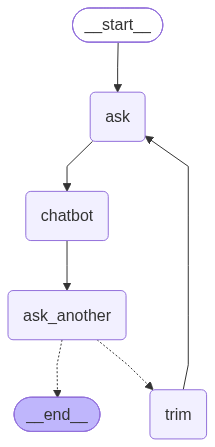

In [71]:
graph_complied = graph.compile()

graph_complied

In [73]:
graph_complied.invoke(MessagesState(messages=[]))

**********

-------> Entering the ask state
What is your Question ?

--------------> Entering Chatbot:
================================== Ai Message ==================================


<think>
Here's a thinking process:

1.  **Identify the User's Question**: The user is asking "who is the pm of italy?" (PM = Prime Minister).
2.  **Determine Current Date/Context**: The system prompt states "Current time: 2026. Knowledge cutoff: 2026." I need to provide the most accurate information based on my training data up to 2026.
3.  **Identify Key Entity**: Prime Minister of Italy.
4.  **Recall/Verify Information**: 
   - As of my last update (2024), the Prime Minister of Italy was Giorgia Meloni, who took office in October 2022.
   - I need to consider if there were any changes between 2024 and 2026. Italian politics can be volatile, but without specific real-time data, I should state the known information up to my cutoff and acknowledge the possibility of changes.
   - I should verify if there

{'messages': [AIMessage(content='What is your Question ?', additional_kwargs={}, response_metadata={}, id='8bc03e30-e7c9-485f-af81-8f13218e1583', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What is her age?', additional_kwargs={}, response_metadata={}, id='d078a954-86eb-4dfc-9548-84a3866839a5'),
  AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User asks: "What is her age?"\n   - Context: Previous question was about the PM of Italy, and I identified Giorgia Meloni as the PM (as of 2026).\n   - So "her" refers to Giorgia Meloni.\n\n2.  **Identify Key Information Needed:**\n   - Need Giorgia Meloni\'s birth date.\n   - Calculate her age as of 2026 (current year in the prompt context).\n   - Verify accuracy.\n\n3.  **Retrieve Knowledge:**\n   - Giorgia Meloni was born on January 15, 1977.\n   - Current year context: 2026.\n   - Age calculation: 2026 - 1977 = 49 years old (if her birthday has passed in 2026, which it would h